Dataset Shape (569, 31)
First 5 rows: 
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst 

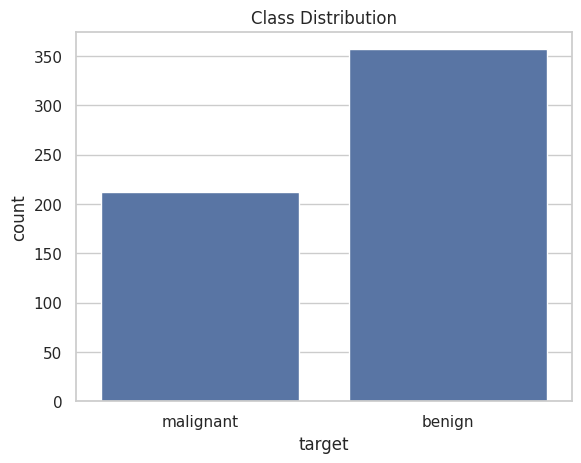

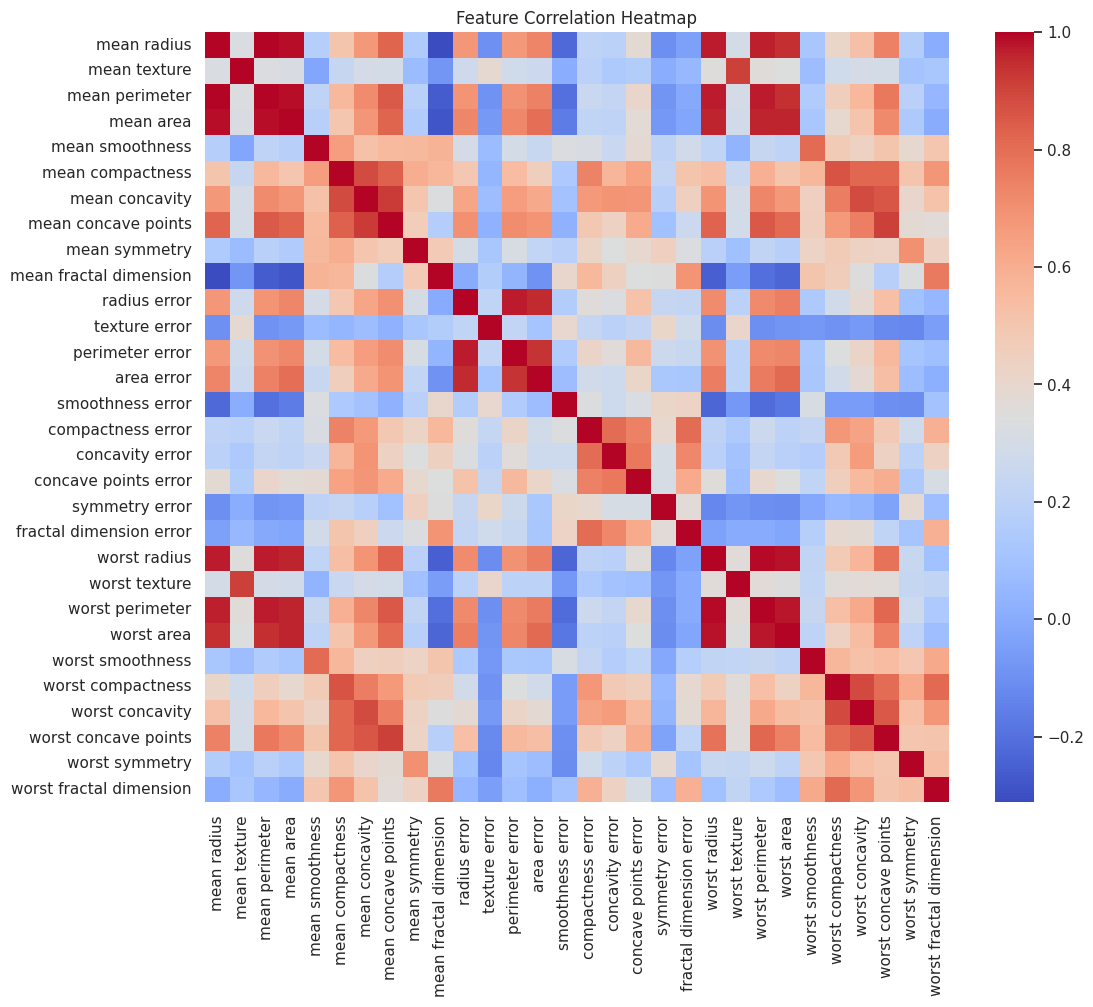

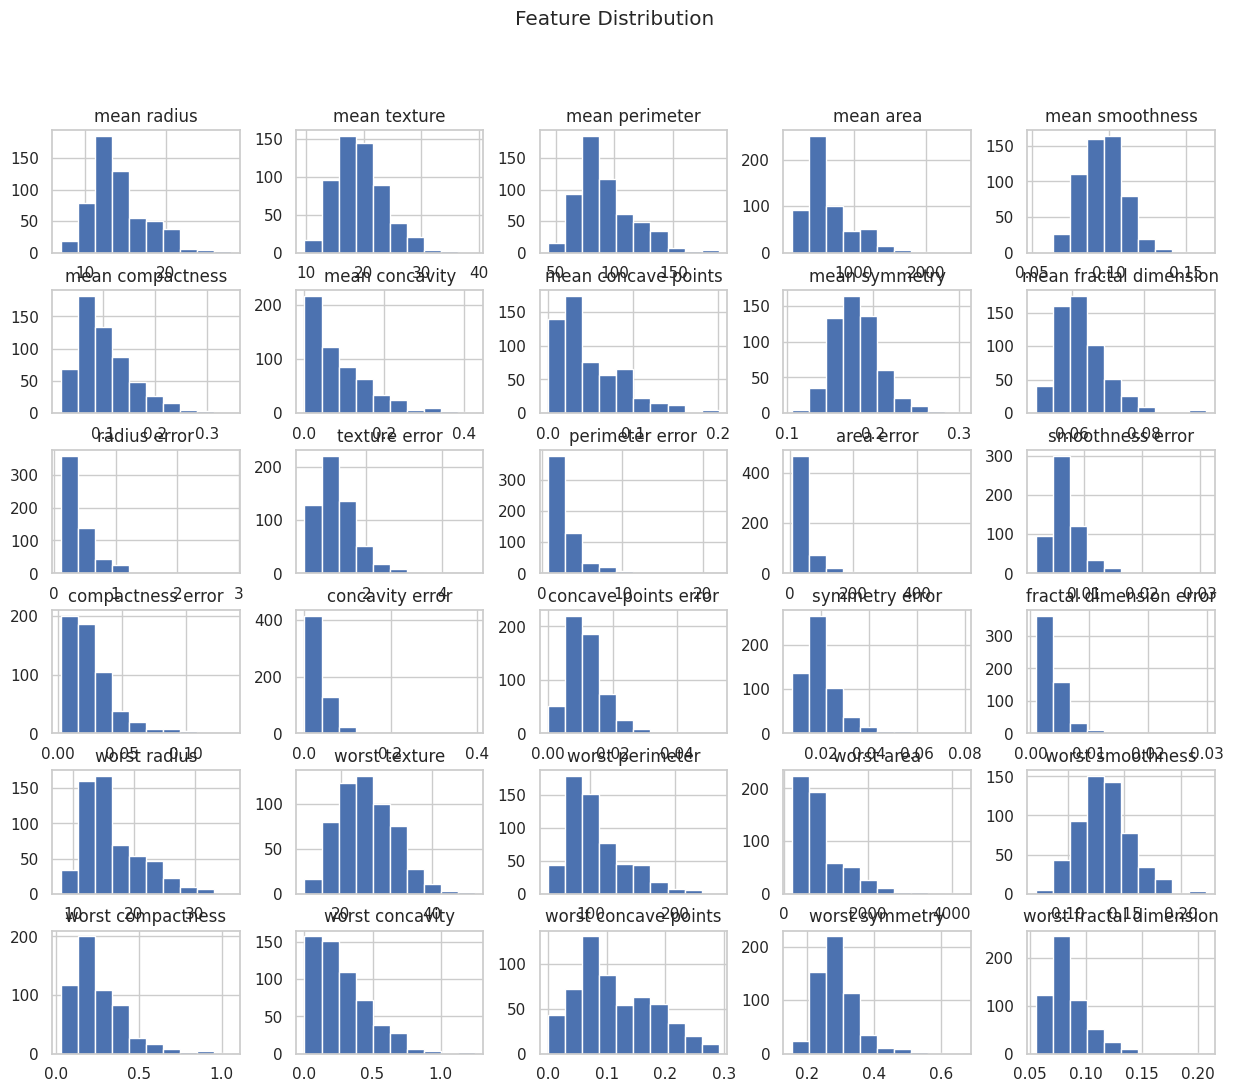

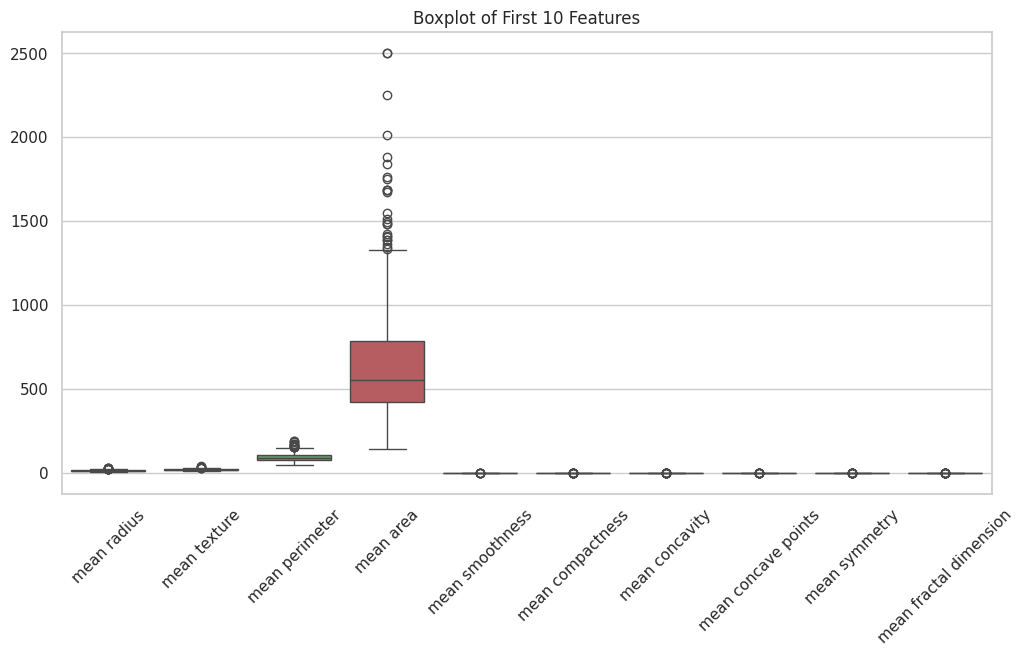

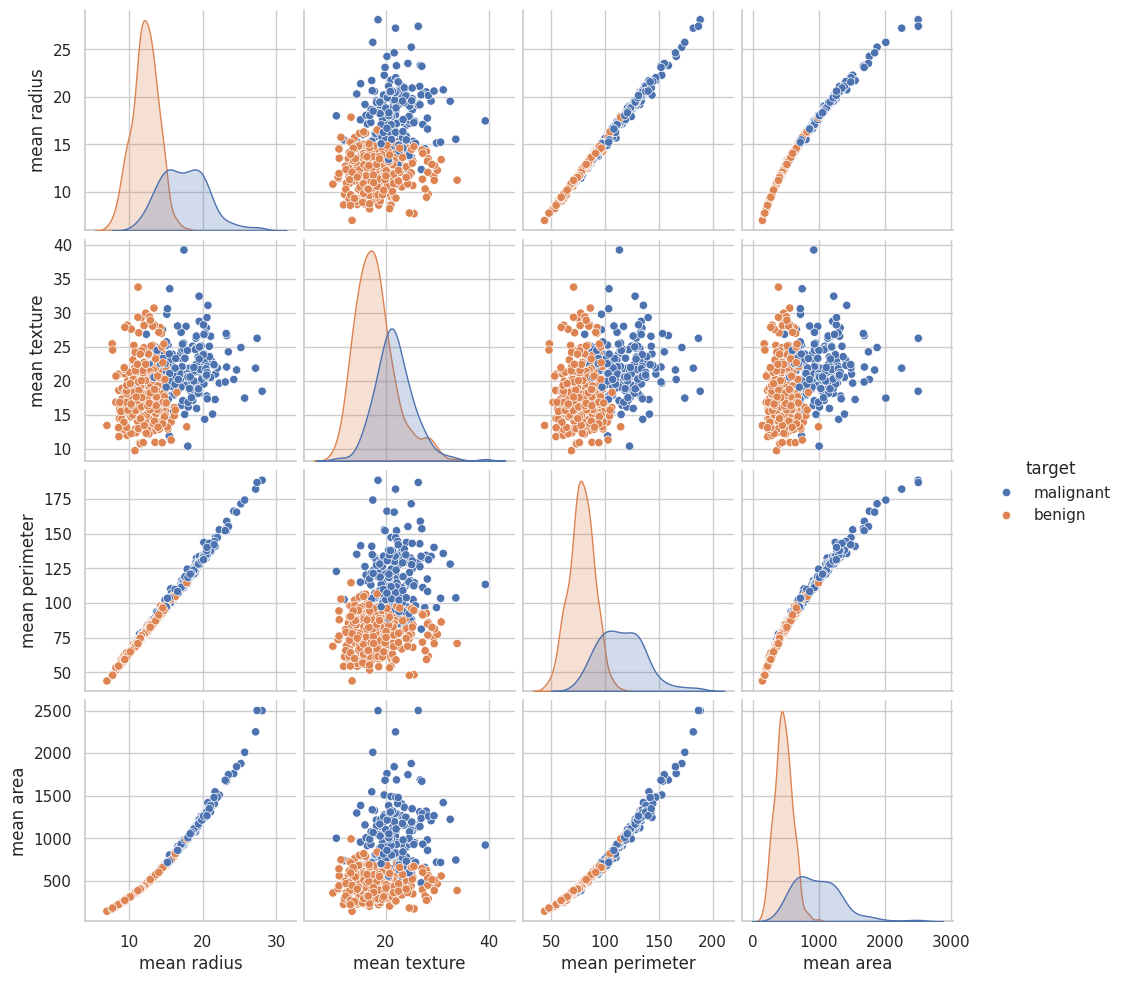

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

sns.set(style = "whitegrid")

data = load_breast_cancer()

data.keys()

df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

df['target'] = df['target'].apply(lambda x: 'malignant' if x == 0 else 'benign')

df.head()
print("Dataset Shape", df.shape)
print("First 5 rows: ")
print(df.head())

print("\nInfo: ")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

plt.figure()
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(12,10))
corr = df.drop('target', axis = 1).corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

df.hist(figsize=(15,12))
plt.suptitle("Feature Distribution")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df.iloc[:, :10])
plt.xticks(rotation=45)
plt.title("Boxplot of First 10 Features")
plt.show()

selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

sns.pairplot(df[selected_features + ['target']], hue='target')
plt.show()

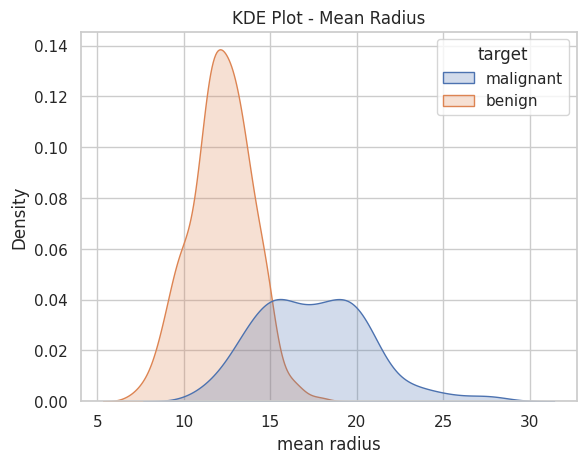

In [5]:
plt.figure()
sns.kdeplot(data=df, x='mean radius', hue='target', fill=True)
plt.title("KDE Plot - Mean Radius")
plt.show()

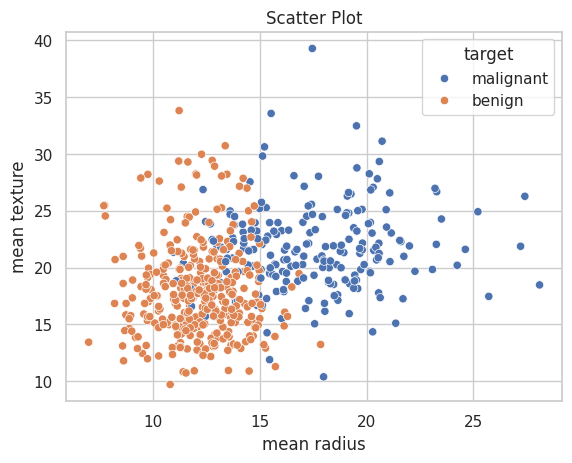

In [6]:
plt.figure()
sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')
plt.title("Scatter Plot")
plt.show()

In [7]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             

In [8]:
print("\nBasic Insights: ")
print("- Dataset has no missing values.")
print("- Benign cases are more frequent than malignant")
print("- Some features show strong correlation (check heatmap)")
print("- Certain features clearly separate classes (see pairplot).")


Basic Insights: 
- Dataset has no missing values.
- Benign cases are more frequent than malignant
- Some features show strong correlation (check heatmap)
- Certain features clearly separate classes (see pairplot).


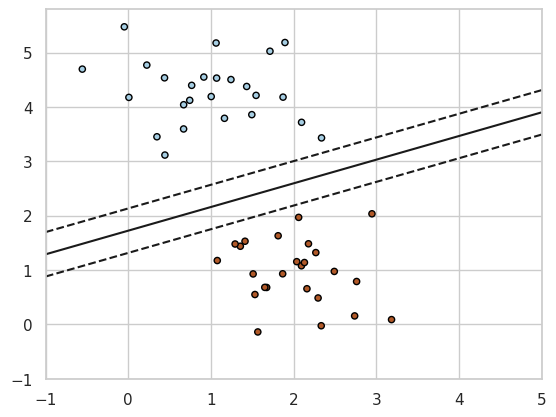

In [9]:
#Activity 2
#Maximum Margin Separating Hyperplane
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_blobs

# we create 50 separable points
X, Y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)

#fit the model
clf = SGDClassifier(loss="hinge", alpha=0.01, max_iter=200)

clf.fit(X, Y)

#plot the line, the points, and the nearest vectors to the plane
xx = np.linspace(-1, 5, 10)
yy = np.linspace(-1, 5, 10)

X1, X2 = np.meshgrid(xx, yy)
Z = np.empty(X1.shape)
for (i, j), val in np.ndenumerate(X1):
  x1 = val
  x2 = X2[i,j]
  p = clf.decision_function([[x1, x2]])
  Z[i,j] = p[0]
levels = [-1.0, 0.0, 1.0]
linestyles = ['dashed', 'solid', 'dashed']
colors = 'k'
plt.contour(X1, X2, Z, levels, colors=colors, linestyles=linestyles)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired,
            edgecolor='black', s=20)
plt.axis('tight')
plt.show()